In [66]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [67]:
df = pd.read_csv("../data/test.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25976 entries, 0 to 25975
Data columns (total 25 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Unnamed: 0                         25976 non-null  int64  
 1   id                                 25976 non-null  int64  
 2   Gender                             25976 non-null  object 
 3   Customer Type                      25976 non-null  object 
 4   Age                                25976 non-null  int64  
 5   Type of Travel                     25976 non-null  object 
 6   Class                              25976 non-null  object 
 7   Flight Distance                    25976 non-null  int64  
 8   Inflight wifi service              25976 non-null  int64  
 9   Departure/Arrival time convenient  25976 non-null  int64  
 10  Ease of Online booking             25976 non-null  int64  
 11  Gate location                      25976 non-null  int

In [68]:
df.head()

,Unnamed: 0,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,0,19556,Female,Loyal Customer,52,Business travel,Eco,160,5,4,...,5,5,5,5,2,5,5,50,44.0,satisfied
1,1,90035,Female,Loyal Customer,36,Business travel,Business,2863,1,1,...,4,4,4,4,3,4,5,0,0.0,satisfied
2,2,12360,Male,disloyal Customer,20,Business travel,Eco,192,2,0,...,2,4,1,3,2,2,2,0,0.0,neutral or dissatisfied
3,3,77959,Male,Loyal Customer,44,Business travel,Business,3377,0,0,...,1,1,1,1,3,1,4,0,6.0,satisfied
4,4,36875,Female,Loyal Customer,49,Business travel,Eco,1182,2,3,...,2,2,2,2,4,2,4,0,20.0,satisfied


In [69]:
df.drop(columns=["Unnamed: 0", "id"], inplace=True)

In [70]:
df.isna().sum()

Gender                                0
Customer Type                         0
Age                                   0
Type of Travel                        0
Class                                 0
Flight Distance                       0
Inflight wifi service                 0
Departure/Arrival time convenient     0
Ease of Online booking                0
Gate location                         0
Food and drink                        0
Online boarding                       0
Seat comfort                          0
Inflight entertainment                0
On-board service                      0
Leg room service                      0
Baggage handling                      0
Checkin service                       0
Inflight service                      0
Cleanliness                           0
Departure Delay in Minutes            0
Arrival Delay in Minutes             83
satisfaction                          0
dtype: int64

In [71]:
df.dropna(inplace=True)

In [72]:
df.duplicated().sum()

0

In [73]:
def label_encoder(df: pd.DataFrame):
    struct = dict()

    for col in df.select_dtypes("object").columns:
        unq = df[col].unique()
        unq_map = {v: k for k, v in enumerate(unq)}
        struct[col] = unq_map
        df[col] = df[col].map(unq_map)

    return df, struct

df_enc = df.copy()
df_enc, struct = label_encoder(df_enc)
df_enc.head()

,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,0,0,52,0,0,160,5,4,3,4,...,5,5,5,5,2,5,5,50,44.0,0
1,0,0,36,0,1,2863,1,1,3,1,...,4,4,4,4,3,4,5,0,0.0,0
2,1,1,20,0,0,192,2,0,2,4,...,2,4,1,3,2,2,2,0,0.0,1
3,1,0,44,0,1,3377,0,0,0,2,...,1,1,1,1,3,1,4,0,6.0,0
4,0,0,49,0,0,1182,2,3,4,3,...,2,2,2,2,4,2,4,0,20.0,0


In [ ]:
def train_test_split(X: pd.DataFrame, y: pd.DataFrame, test_size: float = 0.2, random_state=None):
    if random_state:
        np.random.seed(random_state)

    n_samples = len(X)
    shuffle_indices = np.random.permutation(np.arange(n_samples))

    test_size = round(test_size * n_samples)
    train_size = n_samples - test_size

    train_indices = shuffle_indices[:train_size]
    test_indices = shuffle_indices[test_size:]

    X_train, X_test = X.iloc[train_indices], X.iloc[test_indices]
    y_train, y_test = y.iloc[train_indices], y.iloc[test_indices]

    return X_train, X_test, y_train, y_test

X = df_enc.drop(columns=["satisfaction"])
y = df_enc.satisfaction

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

X_train.head()

,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,...,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes
20726,1,0,44,0,1,3306,2,2,2,2,...,4,4,4,4,4,3,4,5,0,0.0
10051,0,0,30,0,1,2979,2,4,4,4,...,2,2,4,1,4,1,4,2,0,0.0
6749,1,0,40,0,1,449,2,2,2,2,...,5,4,4,4,4,5,4,4,1,16.0
21322,0,0,50,0,1,1090,3,3,3,3,...,5,4,4,4,4,5,4,3,109,97.0
3036,1,0,58,0,1,2116,2,2,2,2,...,4,4,4,4,5,3,4,4,97,73.0


In [ ]:
def min_max_scaler(X: pd.DataFrame):
    return ((X - X.min(axis=0)) / (X.max(axis=0) - X.min(axis=0)))

X_train_mm_scaler = min_max_scaler(X_train)
X_test_mm_scaler = min_max_scaler(X_test)

X_train_mm_scaler.head()

,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,...,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes
20726,1.0,0.0,0.506849,0.0,0.5,0.776212,0.4,0.4,0.4,0.25,...,0.75,0.8,0.8,0.8,0.75,0.5,0.8,1.0,0.000000,0.000000
10051,0.0,0.0,0.315068,0.0,0.5,0.698113,0.4,0.8,0.8,0.75,...,0.25,0.4,0.8,0.2,0.75,0.0,0.8,0.4,0.000000,0.000000
6749,1.0,0.0,0.452055,0.0,0.5,0.093862,0.4,0.4,0.4,0.25,...,1.00,0.8,0.8,0.8,0.75,1.0,0.8,0.8,0.001259,0.020126
21322,0.0,0.0,0.589041,0.0,0.5,0.246955,0.6,0.6,0.6,0.50,...,1.00,0.8,0.8,0.8,0.75,1.0,0.8,0.6,0.137280,0.122013
3036,1.0,0.0,0.698630,0.0,0.5,0.491999,0.4,0.4,0.4,0.25,...,0.75,0.8,0.8,0.8,1.00,0.5,0.8,0.8,0.122166,0.091824


In [76]:
def std_scaler(X: pd.DataFrame):
    return ((X - X.mean(axis=0)) / X.std(axis=0))

X_train_std_scaler = std_scaler(X_train)
X_test_std_scaler = std_scaler(X_test)

X_train_std_scaler.head()

,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,...,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes
20726,1.041506,-0.477273,0.287823,-0.67037,0.594222,2.146940,-0.554781,-0.690357,-0.547418,-0.778349,...,0.421449,0.479497,0.490552,0.497052,0.315419,-0.262965,0.301369,1.287912,-0.386761,-0.392981
10051,-0.959963,-0.477273,-0.640756,-0.67037,0.594222,1.815187,-0.554781,0.602720,0.864121,0.762875,...,-1.089581,-1.003521,0.490552,-1.779685,0.315419,-1.841061,0.301369,-0.980057,-0.386761,-0.392981
6749,1.041506,-0.477273,0.022515,-0.67037,0.594222,-0.751588,-0.554781,-0.690357,-0.547418,-0.778349,...,1.176964,0.479497,0.490552,0.497052,0.315419,1.315131,0.301369,0.531923,-0.359136,0.041188
21322,-0.959963,-0.477273,0.685785,-0.67037,0.594222,-0.101271,0.192867,-0.043818,0.158352,-0.007737,...,1.176964,0.479497,0.490552,0.497052,0.315419,1.315131,0.301369,-0.224067,2.624323,2.239166
3036,1.041506,-0.477273,1.216402,-0.67037,0.594222,0.939643,-0.554781,-0.690357,-0.547418,-0.778349,...,0.421449,0.479497,0.490552,0.497052,1.150142,-0.262965,0.301369,0.531923,2.292828,1.587913


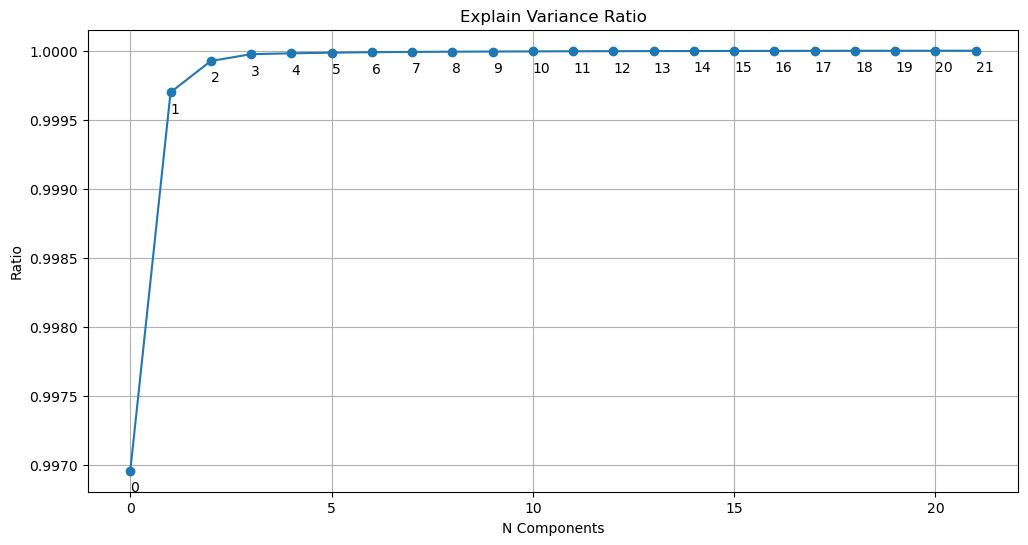

In [77]:
def explain_variance_ratio(X: pd.DataFrame):
    x_centered = X - X.mean()
    cov_matrix = np.cov(x_centered, rowvar=False)
    eigenvalues, _ = np.linalg.eigh(cov_matrix)
    sorted_eigenvalues = np.sort(eigenvalues)[::-1]

    total = sorted_eigenvalues.sum()

    return sorted_eigenvalues / total
  
evr = explain_variance_ratio(X) 
cumsum = np.cumsum(evr)

plt.figure(figsize=(12, 6))
plt.title("Explain Variance Ratio")  
plt.plot(cumsum, marker="o")
plt.title("Explain Variance Ratio")
plt.xlabel("N Components")
plt.ylabel("Ratio")

for i, y in enumerate(cumsum):
    plt.annotate(str(i), (i, y), textcoords="offset points", xytext=(0, -15))

plt.grid(True)
plt.show()

In [78]:
threshold = 0.9998
n_components = np.argmax(cumsum >= threshold) + 1
print(f"N components yang di butuhkan untuk menjelaskan {threshold*100} adalah {n_components}")

N components yang di butuhkan untuk menjelaskan 99.98 adalah 3


In [79]:
def pca(X: pd.DataFrame, n_components: int):
    x_centered = X - X.mean()
    cov_matrix = np.cov(x_centered, rowvar=False)
    eigenvalues, eigenmatrix = np.linalg.eigh(cov_matrix)

    sorted_indices = np.argsort(eigenvalues)[::-1]
    sorted_eigenmatrix = eigenmatrix[:, sorted_indices]

    principal_components = sorted_eigenmatrix[:, :n_components]

    X_pca = np.dot(x_centered, principal_components)
    return pd.DataFrame(X_pca)

X_train_pca_scaler = pca(X_train, n_components=3)
X_test_pca_scaler = pca(X_test, n_components=3)

X_train_pca_scaler.head(10)

,0,1,2
0,-2116.199017,18.563121,-1.775987
1,-1789.180294,18.773054,11.906048
2,740.811905,8.585937,-1.135767
3,99.899178,-125.336548,-10.895063
4,-926.128431,-100.560797,-17.669607
5,787.893549,-100.295202,-2.345454
6,141.822693,12.382152,10.572277
7,1064.793827,20.954700,-10.520551
8,0.881470,-109.921782,-16.619357
9,-1409.181770,19.061787,10.493117


In [ ]:
class KNN:
    def __init__(self, k, p, weight, voting: str = "sort"):
        self.k = k
        self.p = p
        self.weight = weight
        self.voting = voting

    def fit(self, X_train: pd.DataFrame, y_train: pd.DataFrame):
        self.X_train = X_train.to_numpy()
        self.y_train = y_train.to_numpy()

    def _minkowski_distance(self, a, b):
        return np.power(np.sum(np.abs(a - b) ** self.p, axis=1), 1 / self.p)

    def _get_nn(self, X_test: pd.DataFrame):
        distance = self._minkowski_distance(X_test, self.X_train)
        k_idxs = np.argsort(distance)[: self.k]
        k_labels = [self.y_train[i] for i in k_idxs]
        k_distance = [distance[i] for i in k_idxs]

        if self.weight == "uniform":
            values, counts = np.unique(k_labels, return_counts=True)
            max_count = max(counts)
            candidates = values[counts == max_count]

            if self.voting == "sort":
                if len(candidates) >= 1:
                    np.random.choice(candidates)
                else:
                    return sorted(candidates)[0]
            elif self.voting == "default":
                if len(candidates) >= 1:
                    np.random.choice(candidates)
                else:
                    return candidates[0]
            else:
                raise ValueError("voting is doesn't match")

        elif self.weight == "distance":
            weights = [(1 / (d + 1e-5)) for d in k_distance]

        elif callable(self.weight):
            weights = [(1 / (d + 1e-5)) for d in k_distance]

        else:
            raise ValueError("weight params is does't match!")

        label_weight = dict()
        for label, weight in zip(k_labels, weights):
            label_weight[label] = label_weight.get(label, 0) + weight

        max_weight = max(label_weight.values())
        candidates = [label for label, weight in label_weight.items() if weight == max_weight]

        if self.voting == "sort":
            if len(candidates) >= 1:
                np.random.choice(candidates)
            else:
                return sorted(candidates)[0]
        elif self.voting == "default":
            if len(candidates) >= 1:
                np.random.choice(candidates)
            else:
                return candidates[0]
        else:
            raise ValueError("voting is doesn't match")

    def predict(self, X_test: pd.DataFrame):
        return np.array([self._get_nn(x) for x in X_test.to_numpy()])

In [ ]:
class EvaluationModel:
    def __init__(self, y_true: pd.DataFrame, y_pred: np.ndarray):
        self.y_true = y_true
        self.y_pred = y_pred

    def accuracy(self):
        return np.sum(self.y_true == self.y_pred) / len(self.y_true)

    def precision(self, TP, FP):
        return TP / (TP + FP) if (TP + FP) != 0 else 0

    def recall(self, TP, FN):
        return TP / (TP + FN) if (TP + FN) != 0 else 0

    def f1_score(self, TP, FP, FN):
        P = self.precision(TP, FP)
        R = self.precision(TP, FN)

        return 2 * (P * R) / (P + R) if (P + R) != 0 else 0

    def macro_avg(self, report_df: pd.DataFrame):
        return report_df[["Precision", "Recall", "F1-Score"]].mean()

    def weighted_avg(self, report_df: pd.DataFrame):
        class_vc = self.y_true.value_counts()
        total_samples = len(self.y_true)

        weighted_score = dict()
        for col in ["Precision", "Recall", "F1-Score"]:
            weighted_sum = 0
            for i, row in report_df.iterrows():
                if row["Category"] not in ["macro avg", "weighted avg"]:
                    cat = row["Category"]
                    cat_weight = class_vc.get(cat, 0) / total_samples
                    weighted_sum += cat_weight * row[col]

            weighted_score[col] = weighted_sum

        return weighted_score

    def make_report(self):
        cats = pd.Series(self.y_true).unique()
        report_dict = {"Category": [], "Precision": [], "Recall": [], "F1-Score": []}

        for cat in cats:
            # Confusion Matrix
            TP = np.sum(
                (self.y_true == cat) & (self.y_pred == cat)
            )  # Asli POSITIF prediksi POSITIF
            TN = np.sum(
                (self.y_true != cat) & (self.y_pred != cat)
            )  # Asli NEGATIF prediksi NEGATIF
            FP = np.sum(
                (self.y_true != cat) & (self.y_pred == cat)
            )  # Asli NEGATIF prediksi POSITIF
            FN = np.sum(
                (self.y_true == cat) & (self.y_pred != cat)
            )  # Asli POSITIF prediksi NEGATIF
            
            # Calculation Matrix
            P = self.precision(TP, FP)
            R = self.recall(TP, FN)
            F1 = self.f1_score(TP, FP, FN)
            
            # Append Matrix
            report_dict["Category"].append(cat)
            report_dict["Precision"].append(P)
            report_dict["Recall"].append(R)
            report_dict["F1-Score"].append(F1)
        
        accuracy = self.accuracy()
        
        report_df = pd.DataFrame(report_dict)
        macro_avg = self.macro_avg(report_df)
        weighted_avg = self.weighted_avg(report_df)
        
        summary_result = pd.DataFrame.from_records([
          {"Category": "macro avg", **macro_avg},
          {"Category": "weighted avg", **weighted_avg},
        ])
        
        final_report_df = pd.concat([report_df, summary_result], ignore_index=True)
        
        return final_report_df, accuracy

In [82]:
model_1 = KNN(k=7, p=2, weight="distance")
model_1.fit(X_train_std_scaler, y_train)

preds = model_1.predict(X_test_std_scaler)

# Evaluation
eval_model = EvaluationModel(y_true=y_test, y_pred=preds)
report_df, accuracy = eval_model.make_report()

print(f"Accuracy: {accuracy}")
report_df

Accuracy: 0.4943999227575553


,Category,Precision,Recall,F1-Score
0,1,0.598512,0.304090,0.403282
1,0,0.452807,0.738431,0.561377
2,macro avg,0.525659,0.521261,0.482329
3,weighted avg,0.534670,0.494400,0.472553
